# Live Session - Data Visualization_GMID4 (Data Preprocessing or data cleaning)

**27th Sept, 2025**

**Exploratory Data Analysis (EDA)**: EDA is a method of analyzing datasets to summarize their main characteristics using visual and statistical methods, aiming to discover patterns, anomalies, and relationships without pre-existing hypotheses.








- Data recieved is almost never completely clean
- We need to clean up the data
- Also the exploratory phase gives some ideas about the data

# Drive Mounting

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


 # To check working Directory

In [ ]:
import os                 #os is a built-in module that provides functions to interact with the operating system
print(os.getcwd())

/content


In [ ]:
import os                                   # Import module for operating system-related functions
os.chdir('/content/drive/MyDrive/Data_Cleaning')  # Change the current working directory to this folder



In [ ]:
print(os.getcwd())   # Display the current working directory path


/content/drive/MyDrive/Data_Cleaning


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Commands to see overall structure of data (Initial Data) Tests

In [ ]:
df = pd.read_csv("loan_data_set.csv")   # Load the CSV file into a pandas DataFrame


In [ ]:
df.sample(5) #random  5 lines

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
292,LP001940,Male,Yes,2,Graduate,No,3153,1560.0,134.0,360.0,1.0,Urban,Y
265,LP001875,Male,No,0,Graduate,No,4095,3447.0,151.0,360.0,1.0,Rural,Y
496,LP002587,Male,Yes,0,Not Graduate,No,2600,1700.0,107.0,360.0,1.0,Rural,Y


In [ ]:
# No of rows and columns
print("Shape of the dataset:",df.shape)

# Names of the columns
print('Columns:',df.columns)

Shape of the dataset: (614, 13)
Columns: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [ ]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


| Column Name           | Meaning                                                        |
| --------------------- | -------------------------------------------------------------- |
| **Loan_ID**           | Unique identifier for each loan application                    |
| **Gender**            | Gender of the applicant (Male / Female)                        |
| **Married**           | Marital status of applicant (Yes / No)                         |
| **Dependents**        | Number of dependents of the applicant (0, 1, 2, 3+)            |
| **Education**         | Education level of applicant (Graduate / Not Graduate)         |
| **Self_Employed**     | Whether applicant is self-employed (Yes / No)                  |
| **ApplicantIncome**   | Income of the primary applicant                                |
| **CoapplicantIncome** | Income of the co-applicant                                     |
| **LoanAmount**        | Loan amount requested by the applicant                         |
| **Loan_Amount_Term**  | Duration of loan repayment (in months)                         |
| **Credit_History**    | Applicant's past credit history (Good / Bad repayment history) |
| **Property_Area**     | Location of property (Urban / Semiurban / Rural)               |
| **Loan_Status**       | Loan approval status (Approved / Not Approved)                 |


In [ ]:
# from google.colab import sheets
# sheet = sheets.InteractiveSheet(df=df)

In [ ]:
df.tail(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
604,LP002959,Female,Yes,1,Graduate,No,12000,0.0,496.0,360.0,1.0,Semiurban,Y
605,LP002960,Male,Yes,0,Not Graduate,No,2400,3800.0,NaN,180.0,1.0,Urban,N
606,LP002961,Male,Yes,1,Graduate,No,3400,2500.0,173.0,360.0,1.0,Semiurban,Y
607,LP002964,Male,Yes,2,Not Graduate,No,3987,1411.0,157.0,360.0,1.0,Rural,Y
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


#  Some basic Tests

In [ ]:
df.info()   #To print the basic information about data like collumns names and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB



*   count: The number of non-null values.
*   mean: The average value.
*  std: The standard deviation, indicating the spread of the data.
*   min: The minimum value.
*   25%: The 25th percentile (first quartile) or we can say that 25% of the data values are less than or equal to this *number.
*   50%: The 50th percentile (median, second quartile).
*   75%: The 75th percentile (third quartile).
*   max: The maximum value.






In [ ]:
df.describe() # Breif summary statistical distribution of about numerical data

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



 **count**  | Number of non-null entries    
**unique** | Number of unique categories  
**top**    | Most frequent category (mode)

**freq**   | Frequency of the top category


In [ ]:
# data Distribution for non-numerical or object type data
df.describe(include=['O'])

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


# **Some basic Data Cleaning steps**

#1- To count the no. of missing values

In [ ]:
df.isnull()   # Check each cell and return True where values are missing

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,False,False,False,False,False,False,False,False,False,False,False,False,False
610,False,False,False,False,False,False,False,False,False,False,False,False,False
611,False,False,False,False,False,False,False,False,False,False,False,False,False
612,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()   # Count the number of missing (NaN) values in each column


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


# 2 - Out of all rows, how much data is actually present in column?

This code creates a summary table showing how many values are missing in each column and what percentage of data is complete, sorted from least to most complete columns




In [ ]:
# Count missing (NaN) values in each column and convert result to a DataFrame
# reset_index() moves column names from index to a regular column
missing_df = df.isnull().sum().reset_index()
# Rename columns for clarity
missing_df.columns = ['Column Name', 'Missing Values Count']
# Calculate percentage of non-missing values (data completeness) per column
missing_df['Fill Factor (%)'] = (
    df.shape[0] - missing_df['Missing Values Count']
) * 100 / df.shape[0]

# Sort columns by data completeness (least to most complete)
missing_df = missing_df.sort_values('Fill Factor (%)').reset_index(drop=True)

# Display missing value summary
print(missing_df)


          Column Name  Missing Values Count  Fill Factor (%)
0      Credit_History                    50        91.856678
1       Self_Employed                    32        94.788274
2          LoanAmount                    22        96.416938
3          Dependents                    15        97.557003
4    Loan_Amount_Term                    14        97.719870
5              Gender                    13        97.882736
6             Married                     3        99.511401
7             Loan_ID                     0       100.000000
8   CoapplicantIncome                     0       100.000000
9     ApplicantIncome                     0       100.000000
10          Education                     0       100.000000
11      Property_Area                     0       100.000000
12        Loan_Status                     0       100.000000


In [ ]:
# Calculate the total number of missing values across all columns
missing_cnt = missing_df['Missing Values Count'].sum()

# Print the total count of missing values
print(f'Total Number of Missing Values: {missing_cnt}')



Total Number of Missing Values: 149


## 3- Methods to deal with missing values
 - **First** way of dealing with missing values is delete all rows with missing values
 Q.1 what are the consequences??
 Q2. when should we apply this method??


In [ ]:

# Remove all rows that contain at least one missing (NaN) value
df_dropped = df.dropna()

# Display information about the cleaned DataFrame (rows, columns, data types)
df_dropped.info()


<class 'pandas.core.frame.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            480 non-null    object 
 1   Gender             480 non-null    object 
 2   Married            480 non-null    object 
 3   Dependents         480 non-null    object 
 4   Education          480 non-null    object 
 5   Self_Employed      480 non-null    object 
 6   ApplicantIncome    480 non-null    int64  
 7   CoapplicantIncome  480 non-null    float64
 8   LoanAmount         480 non-null    float64
 9   Loan_Amount_Term   480 non-null    float64
 10  Credit_History     480 non-null    float64
 11  Property_Area      480 non-null    object 
 12  Loan_Status        480 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 52.5+ KB


In [ ]:
# Check and confirm that there are no missing (NaN) values remaining in each column
df_dropped.isna().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
# Print how many rows were removed after dropping rows with missing values
print(f'Number of rows removed = {len(df)-len(df_dropped)}')


Number of rows removed = 134


**Note:** It could be problamatic if your removed rows are creating any baisness and if
 your analysis is based on the catogares.





 - **Another way** is that we can drop columns with at least one missing value


In [ ]:
df_dropped_cols = df.dropna(axis=1)   # Drop columns that contain at least one missing (NaN) value

In [ ]:
df_dropped_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Education          614 non-null    object 
 2   ApplicantIncome    614 non-null    int64  
 3   CoapplicantIncome  614 non-null    float64
 4   Property_Area      614 non-null    object 
 5   Loan_Status        614 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 28.9+ KB


In [ ]:
df_dropped_cols.head()

,Loan_ID,Education,ApplicantIncome,CoapplicantIncome,Property_Area,Loan_Status
0,LP001002,Graduate,5849,0.0,Urban,Y
1,LP001003,Graduate,4583,1508.0,Rural,N
2,LP001005,Graduate,3000,0.0,Urban,Y
3,LP001006,Not Graduate,2583,2358.0,Urban,Y
4,LP001008,Graduate,6000,0.0,Urban,Y


In [ ]:
print("Columns in original dataset: %d \n" % df.shape[1])        # Print total number of columns in original DataFrame
print("Columns with na's dropped: %d" % df_dropped_cols.shape[1]) # Print number of columns after dropping those with missing values


Columns in original dataset: 13 

Columns with na's dropped: 6


We've lost 7 columns of data, but at this point we have successfully removed all the NaN's from our data.

#3- Replacing missing values with predefined value

**In some cases instead of dropping the rows or columns with missing values, we can fill them with a value that makes sense**

For this , Let's take small sub-section of the dataset

In [ ]:
subset_df = df.loc[:20]
subset_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
## fill NaNs with a fixed value 0

subset_df_filled_na_0 = subset_df.fillna(0)
subset_df_filled_na_0

# In case of dependent it may work but not in  all cases like  applicant income  etc

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,0.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
subset_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
subset_df_filled_na_back =subset_df.fillna(method = 'bfill', axis=0).fillna(0)
subset_df_filled_na_back


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
subset_df_filled_na_forward=subset_df.fillna(method = 'ffill', axis=0).fillna(0)
subset_df_filled_na_forward

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,0.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Checking null values individually

In [ ]:
df['Credit_History'].unique()

array([ 1.,  0., nan])

In [ ]:
df['Credit_History'].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [ ]:
print(df['Loan_Amount_Term'].unique())


[360. 120. 240.  nan 180.  60. 300. 480.  36.  84.  12.]


In [ ]:
df['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [ ]:

df['Loan_Amount_Term'].median()

360.0

In [ ]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [ ]:
df['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [ ]:
df['Married'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
df['Married'].value_counts()

,count
Married,
Yes,398
No,213


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,489
Female,112


 **Decide a fill stratergy**


In [ ]:
#Lets fix this in original data

df['Credit_History'] = df['Credit_History'].fillna(0)
df['Self_Employed'] = df['Self_Employed'].fillna('No')
df['Dependents'] = df['Dependents'].fillna('0')
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Married'] = df['Married'].fillna('No')

df = df.dropna(subset=['LoanAmount','Gender']).reset_index(drop=True)

Typically you want to remove unnecessary columns first. That way you dont have to deal with missing values in those columns.

# Dropping unnecessary columns

In [ ]:
df.sample(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
192,LP001693,Female,No,0,Graduate,No,3244,0.0,80.0,360.0,1.0,Urban,Y
344,LP002180,Male,No,0,Graduate,Yes,6822,0.0,141.0,360.0,1.0,Rural,Y
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
477,LP002619,Male,Yes,0,Not Graduate,No,3814,1483.0,124.0,300.0,1.0,Semiurban,Y
48,LP001157,Female,No,0,Graduate,No,3086,0.0,120.0,360.0,1.0,Semiurban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            579 non-null    object 
 1   Gender             579 non-null    object 
 2   Married            579 non-null    object 
 3   Dependents         579 non-null    object 
 4   Education          579 non-null    object 
 5   Self_Employed      579 non-null    object 
 6   ApplicantIncome    579 non-null    int64  
 7   CoapplicantIncome  579 non-null    float64
 8   LoanAmount         579 non-null    float64
 9   Loan_Amount_Term   579 non-null    float64
 10  Credit_History     579 non-null    float64
 11  Property_Area      579 non-null    object 
 12  Loan_Status        579 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 58.9+ KB


In [ ]:
#  Dropping Columns in a DataFrame
# Categories of data in a dataset not useful to you.
to_drop = ['Property_Area','CoapplicantIncome']

df_col_dropped = df.drop(to_drop,axis=1)

df_col_dropped.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,128.0,360.0,1.0,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,66.0,360.0,1.0,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,120.0,360.0,1.0,Y
3,LP001008,Male,No,0,Graduate,No,6000,141.0,360.0,1.0,Y
4,LP001011,Male,Yes,2,Graduate,Yes,5417,267.0,360.0,1.0,Y


In [ ]:
#To check which columns contain unique values and understand their usefulness in remaining collumns

for col in df_col_dropped.columns:                     # Loop through each column in the DataFrame
    print(col, df_col_dropped[col].is_unique)          # Print column name and whether all values are unique



Loan_ID True
Gender False
Married False
Dependents False
Education False
Self_Employed False
ApplicantIncome False
LoanAmount False
Loan_Amount_Term False
Credit_History False
Loan_Status False


In [ ]:
df_col_dropped .head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,128.0,360.0,1.0,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,66.0,360.0,1.0,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,120.0,360.0,1.0,Y
3,LP001008,Male,No,0,Graduate,No,6000,141.0,360.0,1.0,Y
4,LP001011,Male,Yes,2,Graduate,Yes,5417,267.0,360.0,1.0,Y


# Changing Index of the DataFrame

In [ ]:
df_col_dropped.set_index('Loan_ID', inplace=True)   # Set 'Loan_ID' as the DataFrame index and remove it from columns
df_col_dropped .head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
Loan_ID,,,,,,,,,,
LP001003,Male,Yes,1,Graduate,No,4583,128.0,360.0,1.0,N
LP001005,Male,Yes,0,Graduate,Yes,3000,66.0,360.0,1.0,Y
LP001006,Male,Yes,0,Not Graduate,No,2583,120.0,360.0,1.0,Y
LP001008,Male,No,0,Graduate,No,6000,141.0,360.0,1.0,Y
LP001011,Male,Yes,2,Graduate,Yes,5417,267.0,360.0,1.0,Y


In [ ]:
# Indexing using the unique ID
df_col_dropped.loc['LP001011']

,LP001011
Gender,Male
Married,Yes
Dependents,2
Education,Graduate
Self_Employed,Yes
ApplicantIncome,5417
LoanAmount,267.0
Loan_Amount_Term,360.0
Credit_History,1.0
Loan_Status,Y


In [ ]:
# Indexing using the row index
df_col_dropped.iloc[0]

,LP001003
Gender,Male
Married,Yes
Dependents,1
Education,Graduate
Self_Employed,No
ApplicantIncome,4583
LoanAmount,128.0
Loan_Amount_Term,360.0
Credit_History,1.0
Loan_Status,N


Changing the index allows us to select rows using a unique identifier or their row id

# Save cleaned data to csv

Lets say we want to drop the rows with missing values and set the index to loan id for our cleaned data.

In [ ]:
df_col_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 579 entries, LP001003 to LP002990
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            579 non-null    object 
 1   Married           579 non-null    object 
 2   Dependents        579 non-null    object 
 3   Education         579 non-null    object 
 4   Self_Employed     579 non-null    object 
 5   ApplicantIncome   579 non-null    int64  
 6   LoanAmount        579 non-null    float64
 7   Loan_Amount_Term  579 non-null    float64
 8   Credit_History    579 non-null    float64
 9   Loan_Status       579 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 65.9+ KB


In [ ]:
df_col_dropped.to_csv('cleaned_loan_data.csv',index=True)

Here we cleaned up our data and saved it as a csv file with `index=True`

Despite that, when we reimport it, the index will 0...n and we have to set the index again manually

In [ ]:
reimport_df = pd.read_csv('cleaned_loan_data.csv')
reimport_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,128.0,360.0,1.0,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,66.0,360.0,1.0,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,120.0,360.0,1.0,Y
3,LP001008,Male,No,0,Graduate,No,6000,141.0,360.0,1.0,Y
4,LP001011,Male,Yes,2,Graduate,Yes,5417,267.0,360.0,1.0,Y


# Inconsistent Values

In [ ]:
df = pd.read_csv('books_data_set.csv')
df.head(10)

,Identifier,Edition Statement,Place of Publication,Date of Publication,Publisher,Title,Author,Contributors,Corporate Author,Corporate Contributors,Former owner,Engraver,Issuance type,Flickr URL,Shelfmarks
0,206,NaN,London,1879 [1878],S. Tinsley & Co.,Walter Forbes. [A novel.] By A. A,A. A.,"FORBES, Walter.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12641.b.30.
1,216,NaN,London; Virtue & Yorston,1868,Virtue & Co.,All for Greed. [A novel. The dedication signed...,"A., A. A.","BLAZE DE BURY, Marie Pauline Rose - Baroness",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12626.cc.2.
2,218,NaN,London,1869,"Bradbury, Evans & Co.",Love the Avenger. By the author of “All for Gr...,"A., A. A.","BLAZE DE BURY, Marie Pauline Rose - Baroness",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12625.dd.1.
3,472,NaN,London,1851,James Darling,"Welsh Sketches, chiefly ecclesiastical, to the...","A., E. S.","Appleyard, Ernest Silvanus.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 10369.bbb.15.
4,480,"A new edition, revised, etc.",London,1857,Wertheim & Macintosh,"[The World in which I live, and my place in it...","A., E. S.","BROOME, John Henry.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 9007.d.28.
5,481,"Fourth edition, revised, etc.",London,1875,William Macintosh,"[The World in which I live, and my place in it...","A., E. S.","BROOME, John Henry.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 9006.ee.10.
6,519,NaN,London,1872,The Author,Lagonells. By the author of Darmayne (F. E. A....,"A., F. E.","ASHLEY, Florence Emily.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 12637.e.3.
7,667,NaN,"pp. 40. G. Bryan & Co: Oxford, 1898",NaN,NaN,"The Coming of Spring, and other poems. By J. A...","A., J.|A., J.","ANDREWS, J. - Writer of Verse",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 011652.g.73.
8,874,NaN,London],1676,NaN,"A Warning to the inhabitants of England, and L...",Remaʿ.,"ADAMS, Mary.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 11645.bb.42.
9,1143,NaN,London,1679,NaN,A Satyr against Vertue. (A poem: supposed to b...,"A., T.","OLDHAM, John.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS 11602.ee.10.(2.)


In [ ]:
df.tail()

,Identifier,Edition Statement,Place of Publication,Date of Publication,Publisher,Title,Author,Contributors,Corporate Author,Corporate Contributors,Former owner,Engraver,Issuance type,Flickr URL,Shelfmarks
8282,4158088,NaN,London,1838,NaN,"The Parochial History of Cornwall, founded on,...","GIDDY, afterwards GILBERT, Davies.","BOASE, Henry Samuel.|HALS, William.|LYSONS, Da...",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS|British Library HMNTS 10...
8283,4158128,NaN,Derby,"1831, 32",M. Mozley & Son,The History and Gazetteer of the County of Der...,"GLOVER, Stephen - of Derby","NOBLE, Thomas.",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS|British Library HMNTS 10...
8284,4159563,NaN,London,[1806]-22,T. Cadell and W. Davies,Magna Britannia; being a concise topographical...,"LYSONS, Daniel - M.A., F.R.S., and LYSONS (Sam...","GREGSON, Matthew.|LYSONS, Samuel - F.R.S",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS|British Library HMNTS 19...
8285,4159587,NaN,Newcastle upon Tyne,1834,Mackenzie & Dent,"An historical, topographical and descriptive v...","Mackenzie, E. (Eneas)","ROSS, M. - of Durham",NaN,NaN,NaN,NaN,monographic,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS|British Library HMNTS 10...
8286,4160339,NaN,London,1834-43,NaN,Collectanea Topographica et Genealogica. [Firs...,NaN,"BANDINEL, Bulkeley.|Nichols, John Gough",NaN,NaN,NaN,NaN,continuing,http://www.flickr.com/photos/britishlibrary/ta...,British Library HMNTS|British Library HMNTS 79...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8287 entries, 0 to 8286
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Identifier              8287 non-null   int64  
 1   Edition Statement       773 non-null    object 
 2   Place of Publication    8287 non-null   object 
 3   Date of Publication     8106 non-null   object 
 4   Publisher               4092 non-null   object 
 5   Title                   8287 non-null   object 
 6   Author                  6509 non-null   object 
 7   Contributors            8287 non-null   object 
 8   Corporate Author        0 non-null      float64
 9   Corporate Contributors  0 non-null      float64
 10  Former owner            1 non-null      object 
 11  Engraver                0 non-null      float64
 12  Issuance type           8287 non-null   object 
 13  Flickr URL              8287 non-null   object 
 14  Shelfmarks              8287 non-null   

In [ ]:
len(df)

8287

In [ ]:
to_drop = ['Edition Statement',
           'Corporate Author',
           'Corporate Contributors',
           'Former owner',
           'Engraver',
           'Contributors',
           'Issuance type',
           'Shelfmarks',
           'Flickr URL']

df.drop(to_drop, inplace = True, axis = 1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8287 entries, 0 to 8286
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Identifier            8287 non-null   int64 
 1   Place of Publication  8287 non-null   object
 2   Date of Publication   8106 non-null   object
 3   Publisher             4092 non-null   object
 4   Title                 8287 non-null   object
 5   Author                6509 non-null   object
dtypes: int64(1), object(5)
memory usage: 388.6+ KB


In [ ]:
old_len = len(df)
df.dropna(inplace=True)
print(f'Number of rows dropped: {old_len - len(df)}')
print(f'Length of new dataframe: {len(df)}')

Number of rows dropped: 5225
Length of new dataframe: 3062


In [ ]:
df.head()

,Identifier,Place of Publication,Date of Publication,Publisher,Title,Author
0,206,London,1879 [1878],S. Tinsley & Co.,Walter Forbes. [A novel.] By A. A,A. A.
1,216,London; Virtue & Yorston,1868,Virtue & Co.,All for Greed. [A novel. The dedication signed...,"A., A. A."
2,218,London,1869,"Bradbury, Evans & Co.",Love the Avenger. By the author of “All for Gr...,"A., A. A."
3,472,London,1851,James Darling,"Welsh Sketches, chiefly ecclesiastical, to the...","A., E. S."
4,480,London,1857,Wertheim & Macintosh,"[The World in which I live, and my place in it...","A., E. S."


# Setting Index

In [ ]:
print(df['Publisher'].is_unique)
print(df['Identifier'].is_unique)

False
True


In [ ]:
df.set_index('Identifier', inplace = True)
df.head()

,Place of Publication,Date of Publication,Publisher,Title,Author
Identifier,,,,,
206,London,1879 [1878],S. Tinsley & Co.,Walter Forbes. [A novel.] By A. A,A. A.
216,London; Virtue & Yorston,1868,Virtue & Co.,All for Greed. [A novel. The dedication signed...,"A., A. A."
218,London,1869,"Bradbury, Evans & Co.",Love the Avenger. By the author of “All for Gr...,"A., A. A."
472,London,1851,James Darling,"Welsh Sketches, chiefly ecclesiastical, to the...","A., E. S."
480,London,1857,Wertheim & Macintosh,"[The World in which I live, and my place in it...","A., E. S."


In [ ]:
df.loc[206]

,206
Place of Publication,London
Date of Publication,1879 [1878]
Publisher,S. Tinsley & Co.
Title,Walter Forbes. [A novel.] By A. A
Author,A. A.


In [ ]:
df.iloc[206]

,198332
Place of Publication,Albany
Date of Publication,1869
Publisher,Joel Munsell
Title,"Sailing Directions of Henry Hudson, prepared f..."
Author,"BÁRĐARSON, Ívar."


## Cleaning up the Date of Publication column

In [ ]:
df['Date of Publication'].head(20)

,Date of Publication
Identifier,
206,1879 [1878]
216,1868
218,1869
472,1851
480,1857
481,1875
519,1872
2854,1865
3131,1899


In [ ]:
unwanted_characters = ['[', ',', '-']          # Characters used to detect or clean invalid date formats

def clean_dates(item):                          # Function to clean the 'Date of Publication' field
    dop = str(item.loc['Date of Publication'])  # Convert date value to string

    if dop[0] == '[':                           # If date starts with '[', treat it as invalid
        return np.nan                           # Replace with NaN

    for character in unwanted_characters:       # Loop through unwanted characters
        if character in dop:                    # If character exists in date string
            character_index = dop.find(character)
            dop = dop[:character_index].strip() # Keep only valid part and remove extra spaces
                                                     #.strip()removes any extra spaces left after cutting

    return dop                                  # Return cleaned date value


In [ ]:
clean_dates(df.loc[218])

'1869'

In [ ]:
df['Date of Publication']=df.apply(clean_dates,axis=1)

In [ ]:
df['Date of Publication'].head(10)

Now Let's deal with place of publication

In [ ]:
df['Place of Publication'].unique()

In [ ]:
print(len(df['Place of Publication'].unique()))

In [ ]:
df['Place of Publication'].tail(20)

In [ ]:
df.head()

In [ ]:
def clean_location(item):
    pop = item['Place of Publication']
    if ';' in pop:
        pop = pop[:pop.find(';')] # We are removing everything before semicolon
    return pop

In [ ]:
df['Place of Publication'] = df.apply(clean_location, axis=1)
df.head(20)


In [ ]:
df['Place of Publication'].unique()
print(len(df['Place of Publication'].unique()))

Lets look at another data, this is representative of grabbing data from an unstructures source for example a website etc

![](./screencap.png)

# Fixing Column headers

In [ ]:
df = pd.read_csv('olympics_data_set.csv')

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,NaN,? Summer,01 !,02 !,03 !,Total,? Winter,01 !,02 !,03 !,Total,? Games,01 !,02 !,03 !,Combined total
1,Afghanistan (AFG),13,0,0,2,2,0,0,0,0,0,13,0,0,2,2
2,Algeria (ALG),12,5,2,8,15,3,0,0,0,0,15,5,2,8,15
3,Argentina (ARG),23,18,24,28,70,18,0,0,0,0,41,18,24,28,70
4,Armenia (ARM),5,1,2,9,12,6,0,0,0,0,11,1,2,9,12


In [ ]:
df = pd.read_csv('olympics_data_set.csv',skiprows=1,header=0)  #Lets skip the row
df.head()

,Unnamed: 0,? Summer,01 !,02 !,03 !,Total,? Winter,01 !.1,02 !.1,03 !.1,Total.1,? Games,01 !.2,02 !.2,03 !.2,Combined total
0,Afghanistan (AFG),13,0,0,2,2,0,0,0,0,0,13,0,0,2,2
1,Algeria (ALG),12,5,2,8,15,3,0,0,0,0,15,5,2,8,15
2,Argentina (ARG),23,18,24,28,70,18,0,0,0,0,41,18,24,28,70
3,Armenia (ARM),5,1,2,9,12,6,0,0,0,0,11,1,2,9,12
4,Australasia (ANZ) [ANZ],2,3,4,5,12,0,0,0,0,0,2,3,4,5,12


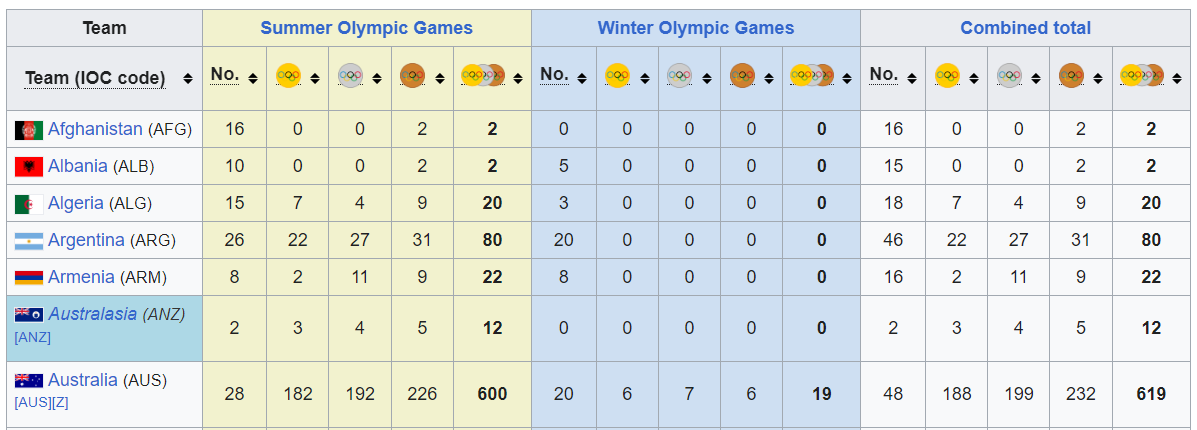

In [ ]:
from IPython.display import Image
Image(filename='screencap.png')

In [ ]:
print(df.shape)
#print(len(df))


(147, 16)


In [ ]:
df.columns

Index(['Unnamed: 0', '? Summer', '01 !', '02 !', '03 !', 'Total', '? Winter',
       '01 !.1', '02 !.1', '03 !.1', 'Total.1', '? Games', '01 !.2', '02 !.2',
       '03 !.2', 'Combined total'],
      dtype='object')

In [ ]:
new_names = {'Unnamed: 0': 'Country',    # Rename the existing columns in readable form by making Dictionary
             '? Summer': 'Summer Olympics',
             '01 !': 'Summer Gold',
             '02 !': 'Summer Silver',
             '03 !': 'Summer Bronze',
             'Total': 'Summer Total',
             '? Winter': 'Winter Olympics',
             '01 !.1': 'Winter Gold',
             '02 !.1': 'Winter Silver',
             '03 !.1': 'Winter Bronze',
             'Total.1': 'Winter Total',
             '? Games': 'Total Games',
             '01 !.2': 'Gold',
             '02 !.2': 'Silver',
             '03 !.2': 'Bronze',
             'Combined Total': 'Combined Total'}

df.rename(columns=new_names,inplace=True)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.tail()

In [ ]:
df = df.drop(df.index[-1],axis =0)
df.tail()

In [ ]:
df.describe()

In [ ]:
df['Country'].is_unique

In [ ]:
(df['Country'].str.extract(r'\(([^)]+)\)'))
# Extracts the text inside parentheses (e.g., country codes) from the 'Country' column using regex


In [ ]:
df.head()

In [ ]:

df['Country Code'] = df['Country'].str.extract(r'\(([^)]+)\)')[0]  # Extract country code from parentheses and store it in a new column
df.head()                                                          # Display the first few rows of the DataFrame


In [ ]:
df.set_index('Country Code', inplace = True)

# Plotting the values

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df, x="Combined total")
plt.show()


In [ ]:
sns.histplot(data=df, x="Combined total",log_scale=True)
plt.show()

What log_scale=True does



*   By default, histograms use a linear scale:
*   each tick on the axis is evenly spaced.



With log_scale=True, seaborn (and matplotlib under the hood) makes the axis logarithmic.

That means:

Each tick mark increases by a power of 10 (or another base), not by a constant step.

In [ ]:
melted_df=df.melt(id_vars= 'Country', value_vars=['Summer Total','Winter Total','Combined total'])

In [ ]:
melted_df.head()

In [ ]:
melted_df.tail()

In [ ]:
sns.barplot(data=melted_df,x='value',y='variable')
plt.show()